# Figure 4: Cross-Phase Structural Comparison

This notebook implements **multiscale structural comparison** between the hierarchical trees obtained from LRG analysis across different experimental phases.

## Key Concept: Multiscale Structural Similarity

The challenge: How do we compare two hierarchical structures (dendrograms)?

### Why simple partition comparison is insufficient:

Cutting a dendrogram at a single threshold gives one partition, but:
- The threshold choice is somewhat arbitrary (even with PSI-optimal selection)
- We lose information about the hierarchical structure
- Two very different trees could produce similar partitions at one level

### Our approach: Multiscale ARI

We compare partitions at **all scales** (threshold levels):

1. For normalized threshold $h \in [0, 1]$ (fraction of max dendrogram height):
   - Cut both dendrograms at height $h \cdot D_{\max}$
   - Obtain partitions $P_A(h)$ and $P_B(h)$
   - Compute Adjusted Rand Index: $\text{ARI}(h) = \text{ARI}(P_A(h), P_B(h))$

2. Compute **structural distance** as integral of divergence:
   $$D_{\text{struct}} = \int_0^1 (1 - \text{ARI}(h)) \, dh$$

**Interpretation**:
- $D = 0$: Identical hierarchical structures at all scales
- $D = 1$: Completely different at all scales
- Intermediate: Captures "at which scale do structures diverge?"

## Figure Layout

1. **4-column comparison**: Network + Dendrogram for each phase
2. **Multiscale ARI curves**: ARI(h) for each phase pair
3. **Triangular distance matrix**: Pairwise structural distances

In [1]:
# Setup
from lrgsglib.config.funcs import move_to_rootf
move_to_rootf(pathname='lrgeegfc')

from lrg_eegfc.notebook import *
path_figs = setup_notebook('figures/presentation_figures')

Current working directory: /home/giulio/Documents/research/neural_networks/lrgeegfc
✓ Notebook setup complete
  Figure output: data/figures/presentation_figures


In [ ]:
# Additional imports
import sys
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import numpy as np
from pathlib import Path
from scipy.cluster.hierarchy import dendrogram, fcluster
from scipy.cluster import hierarchy
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import adjusted_rand_score
from itertools import combinations

# Add notebook directory to path for local imports
notebook_dir = Path("ipynb/06_presentation_figures").resolve()
if str(notebook_dir) not in sys.path:
    sys.path.insert(0, str(notebook_dir))

from presentation_utils import (
    compute_multiscale_ari,
    compute_multiscale_structural_distance,
    compute_phase_distance_matrix_multiscale,
    plot_network_with_partition,
    plot_dendrogram_with_partition,
    plot_triangular_distance_matrix,
    get_cluster_colors,
    CLUSTER_PALETTE,
)

## Configuration

In [3]:
# ============================================================================
# CONFIGURATION
# ============================================================================
PATIENT = "Pat_02"
BAND = "beta"  # Start with beta, easily changeable
PHASES = list(PHASE_LABELS)  # rsPre, taskLearn, taskTest, rsPost

# Analysis parameters
N_THRESHOLDS = 100  # Number of threshold levels for multiscale analysis

# Layout parameters
LAYOUT_K = 0.1
LAYOUT_SEED = 42

# Paths
MSC_CACHE = Path("data/msc_cache")
LRG_CACHE = Path("data/lrg_cache")
OUTPUT_DIR = path_figs / PATIENT
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Patient: {PATIENT}")
print(f"Band: {BAND}")
print(f"Phases: {PHASES}")
print(f"N thresholds: {N_THRESHOLDS}")

Patient: Pat_02
Band: beta
Phases: ['rsPre', 'taskLearn', 'taskTest', 'rsPost']
N thresholds: 100


## Load Data

In [4]:
from lrg_eegfc.workflow.lrg import load_lrg_result
from lrg_eegfc.workflow.msc import load_msc_matrix

# Load LRG results and MSC matrices for all phases
lrg_results = {}
msc_matrices = {}

for phase in PHASES:
    # LRG result
    lrg = load_lrg_result(PATIENT, phase, BAND, "msc", cache_root=LRG_CACHE)
    if lrg is None:
        print(f"ERROR: Missing LRG for {phase}")
        continue
    lrg_results[phase] = lrg
    
    # MSC matrix
    msc = load_msc_matrix(
        PATIENT, phase, BAND,
        cache_root=MSC_CACHE,
        sparsify="none",
    )
    if msc is None:
        print(f"ERROR: Missing MSC for {phase}")
        continue
    msc_matrices[phase] = msc
    
    print(f"Loaded {phase}: {lrg.n_nodes} nodes, threshold={lrg.optimal_threshold:.4f}")

print(f"\nLoaded {len(lrg_results)} phases successfully")

Loaded rsPre: 117 nodes, threshold=0.3644
Loaded taskLearn: 117 nodes, threshold=0.2834
Loaded taskTest: 117 nodes, threshold=0.2419
Loaded rsPost: 117 nodes, threshold=0.4159

Loaded 4 phases successfully


In [ ]:
# ============================================================================
# CLUSTER MATCHING UTILITIES
# ============================================================================
# These functions match clusters across phases using Jaccard similarity
# so that corresponding clusters get the same color.
# IMPORTANT: Each phase gets UNIQUE colors - no two clusters share a color.

from scipy.cluster.hierarchy import to_tree

# Custom color palette - 12 distinct colors, NO YELLOW
CLUSTER_COLORS_HEX = [
    '#e41a1c',  # red
    '#377eb8',  # blue
    '#4daf4a',  # green
    '#984ea3',  # purple
    '#ff7f00',  # orange
    '#a65628',  # brown
    '#f781bf',  # pink
    '#17becf',  # cyan
    '#8dd3c7',  # teal
    '#bebada',  # lavender
    '#fb8072',  # salmon
    '#80b1d3',  # light blue
]

def get_cluster_assignments(linkage_matrix: np.ndarray, n_nodes: int, n_clusters: int) -> np.ndarray:
    """Get cluster assignment for each node given n_clusters."""
    return fcluster(linkage_matrix, n_clusters, criterion='maxclust')

def compute_jaccard_matrix(labels_a: np.ndarray, labels_b: np.ndarray) -> np.ndarray:
    """Compute Jaccard similarity between all pairs of clusters."""
    clusters_a = np.unique(labels_a)
    clusters_b = np.unique(labels_b)

    jaccard = np.zeros((len(clusters_a), len(clusters_b)))

    for i, ca in enumerate(clusters_a):
        set_a = set(np.where(labels_a == ca)[0])
        for j, cb in enumerate(clusters_b):
            set_b = set(np.where(labels_b == cb)[0])
            intersection = len(set_a & set_b)
            union = len(set_a | set_b)
            jaccard[i, j] = intersection / union if union > 0 else 0

    return jaccard, clusters_a, clusters_b

def match_clusters_hungarian(labels_ref: np.ndarray, labels_target: np.ndarray) -> dict:
    """Match clusters from target to reference using Hungarian algorithm.

    Returns mapping: target_cluster -> (ref_cluster, jaccard_score)
    """
    jaccard, clusters_ref, clusters_target = compute_jaccard_matrix(labels_ref, labels_target)
    cost_matrix = 1 - jaccard
    n_ref = len(clusters_ref)
    n_target = len(clusters_target)

    if n_ref != n_target:
        max_n = max(n_ref, n_target)
        padded_cost = np.ones((max_n, max_n))
        padded_cost[:n_ref, :n_target] = cost_matrix
        row_ind, col_ind = linear_sum_assignment(padded_cost)
    else:
        row_ind, col_ind = linear_sum_assignment(cost_matrix)

    # Return mapping with Jaccard scores for filtering
    mapping = {}
    for target_idx, ref_idx in zip(col_ind[:n_target], row_ind[:n_target]):
        if target_idx < n_target and ref_idx < n_ref:
            mapping[clusters_target[target_idx]] = (clusters_ref[ref_idx], jaccard[ref_idx, target_idx])
        elif target_idx < n_target:
            mapping[clusters_target[target_idx]] = (None, 0.0)

    return mapping

def compute_matched_cluster_colors(
    lrg_results: dict,
    phases: list,
    n_communities: int,
    reference_phase: str = None,
) -> tuple:
    """Compute consistent cluster colors across all phases.

    ENSURES NO DUPLICATE COLORS WITHIN A PHASE.

    Returns:
        phase_node_colors: dict of phase -> list of RGBA colors for each node
        cluster_assignments: dict of phase -> cluster labels array
        phase_cluster_color_maps: dict of phase -> {cluster_label: hex_color}
    """
    if reference_phase is None:
        reference_phase = phases[0]

    # Get cluster assignments for all phases
    cluster_assignments = {}
    for phase in phases:
        lrg = lrg_results[phase]
        labels = get_cluster_assignments(lrg.linkage_matrix, lrg.n_nodes, n_communities)
        cluster_assignments[phase] = labels

    # Reference phase: assign colors by cluster size (largest gets color 0)
    ref_labels = cluster_assignments[reference_phase]
    ref_clusters = np.unique(ref_labels)
    ref_sizes = [(c, np.sum(ref_labels == c)) for c in ref_clusters]
    ref_sizes.sort(key=lambda x: -x[1])  # Sort by size descending
    ref_cluster_to_color = {c: i for i, (c, _) in enumerate(ref_sizes)}

    # Build color maps and node colors for each phase
    phase_node_colors = {}
    phase_cluster_color_maps = {}

    for phase in phases:
        labels = cluster_assignments[phase]
        n_nodes = len(labels)
        phase_clusters = np.unique(labels)

        if phase == reference_phase:
            # Reference phase: use size-based assignment
            cluster_to_color = ref_cluster_to_color.copy()
        else:
            # Other phases: match to reference, ensuring NO DUPLICATE COLORS
            mapping = match_clusters_hungarian(ref_labels, labels)

            cluster_to_color = {}
            used_colors = set()

            # First pass: assign colors to well-matched clusters (Jaccard > 0.1)
            matched_pairs = []
            for target_cluster, (ref_cluster, jaccard_score) in mapping.items():
                if ref_cluster is not None and jaccard_score > 0.1:
                    matched_pairs.append((target_cluster, ref_cluster, jaccard_score))

            # Sort by Jaccard score (best matches first get priority)
            matched_pairs.sort(key=lambda x: -x[2])

            for target_cluster, ref_cluster, _ in matched_pairs:
                color_idx = ref_cluster_to_color[ref_cluster]
                if color_idx not in used_colors:
                    cluster_to_color[target_cluster] = color_idx
                    used_colors.add(color_idx)

            # Second pass: assign remaining colors to unmatched clusters
            all_colors = set(range(len(CLUSTER_COLORS_HEX)))
            available_colors = sorted(all_colors - used_colors)

            for target_cluster in phase_clusters:
                if target_cluster not in cluster_to_color:
                    if available_colors:
                        color_idx = available_colors.pop(0)
                    else:
                        # Fallback (shouldn't happen with 12 colors and 8 clusters)
                        color_idx = len(used_colors) % len(CLUSTER_COLORS_HEX)
                    cluster_to_color[target_cluster] = color_idx
                    used_colors.add(color_idx)

        # Build cluster -> hex color map
        cluster_color_map = {cl: CLUSTER_COLORS_HEX[idx] for cl, idx in cluster_to_color.items()}
        phase_cluster_color_maps[phase] = cluster_color_map

        # Build node colors (RGBA)
        node_colors = [
            plt.matplotlib.colors.to_rgba(cluster_color_map[labels[i]])
            for i in range(n_nodes)
        ]
        phase_node_colors[phase] = node_colors

    return phase_node_colors, cluster_assignments, phase_cluster_color_maps

def get_link_color_func(linkage_matrix, cluster_labels, color_map, n_nodes, threshold):
    """Create a function that colors dendrogram links by matched cluster.

    Links below threshold with pure subtrees get colored by cluster.
    Links above threshold or with mixed subtrees get black.
    """
    tree_root, tree_nodes = to_tree(linkage_matrix, rd=True)
    merge_heights = linkage_matrix[:, 2]

    # For each node, find ALL unique clusters in its subtree
    node_clusters = {}

    def get_node_clusters(node):
        if node.id in node_clusters:
            return node_clusters[node.id]

        if node.is_leaf():
            clusters = {cluster_labels[node.id]}
        else:
            left_clusters = get_node_clusters(node.get_left())
            right_clusters = get_node_clusters(node.get_right())
            clusters = left_clusters | right_clusters

        node_clusters[node.id] = clusters
        return clusters

    get_node_clusters(tree_root)

    def link_color_func(node_id):
        if node_id < n_nodes:
            # Leaf - use its cluster color
            cluster = cluster_labels[node_id]
            return color_map.get(cluster, 'gray')

        link_idx = node_id - n_nodes
        height = merge_heights[link_idx]

        if height > threshold:
            return 'black'

        # Get clusters in this subtree
        clusters = node_clusters.get(node_id, set())

        if len(clusters) == 1:
            # Pure subtree - color by its cluster
            cluster = list(clusters)[0]
            return color_map.get(cluster, 'gray')
        else:
            # Mixed subtree below threshold - use black
            return 'black'

    return link_color_func

print("Cluster matching utilities defined.")
print(f"Color palette: {len(CLUSTER_COLORS_HEX)} distinct colors (no yellow)")

In [ ]:
def create_four_phase_figure(
    lrg_results: dict,
    msc_matrices: dict,
    phases: list,
    band: str,
    patient: str,
    k: float = 0.1,
    seed: int = 42,
    figsize: tuple = (22, 14),
    edge_power: float = 2.0,
    max_width: float = 4.0,
    n_communities: int = 8,
) -> plt.Figure:
    """Create 4-column phase comparison figure with MATCHED cluster colors.
    
    Layout:
    - Row 1: Networks with partition colors (power-law edge scaling)
    - Row 2: Dendrograms with colored branches (log scale)
    
    Colors are matched across phases using Hungarian algorithm on Jaccard similarity.
    """
    n_phases = len(phases)
    fig, axes = plt.subplots(2, n_phases, figsize=figsize)
    
    # Compute shared layout from first phase using backbone
    first_phase = phases[0]
    G_first = nx.from_numpy_array(msc_matrices[first_phase])
    weights_first = np.array([G_first[u][v]["weight"] for u, v in G_first.edges()])
    layout_threshold = np.percentile(weights_first, 75)
    
    G_backbone = nx.Graph()
    G_backbone.add_nodes_from(G_first.nodes())
    for u, v in G_first.edges():
        if G_first[u][v]["weight"] >= layout_threshold:
            G_backbone.add_edge(u, v, weight=G_first[u][v]["weight"])
    shared_pos = nx.spring_layout(G_backbone, seed=seed, k=k, iterations=100)
    
    # COMPUTE MATCHED CLUSTER COLORS ACROSS ALL PHASES
    phase_node_colors, cluster_assignments, phase_cluster_color_maps = compute_matched_cluster_colors(
        lrg_results, phases, n_communities, reference_phase=phases[0]
    )
    
    # Colormap for edges
    cmap_edges = plt.colormaps['viridis']
    
    for i, phase in enumerate(phases):
        lrg = lrg_results[phase]
        msc = msc_matrices[phase]
        n_nodes = lrg.n_nodes
        
        # Get matched colors for this phase
        node_colors = phase_node_colors[phase]
        labels = cluster_assignments[phase]
        cluster_color_map = phase_cluster_color_maps[phase]
        n_clusters = len(np.unique(labels))
        
        # Get threshold for n_communities
        merge_heights = lrg.linkage_matrix[:, 2]
        cut_idx = n_nodes - n_communities
        if cut_idx < len(merge_heights) and cut_idx > 0:
            threshold = (merge_heights[cut_idx - 1] + merge_heights[cut_idx]) / 2
        elif cut_idx == 0:
            threshold = merge_heights[0] / 2
        else:
            threshold = lrg.optimal_threshold
        
        # =====================================================================
        # TOP ROW: Network with matched colors
        # =====================================================================
        ax_net = axes[0, i]
        G = nx.from_numpy_array(msc)
        
        edges = list(G.edges(data=True))
        weights = np.array([e[2]['weight'] for e in edges])
        scaled = np.power(weights, edge_power)
        widths = max_width * scaled
        alphas = np.power(weights, edge_power)
        edge_colors = [(*cmap_edges(w)[:3], a) for w, a in zip(weights, alphas)]
        
        nx.draw_networkx_nodes(
            G, shared_pos, ax=ax_net,
            node_size=80,
            node_color=node_colors,
            alpha=0.9,
            edgecolors='white',
            linewidths=0.5,
        )
        nx.draw_networkx_edges(G, shared_pos, ax=ax_net, width=widths, edge_color=edge_colors)
        ax_net.set_title(f"{phase}\n({n_clusters} communities)", fontsize=14, fontweight='bold')
        ax_net.axis('off')
        
        # =====================================================================
        # BOTTOM ROW: Dendrogram with COLORED BRANCHES
        # =====================================================================
        ax_dendro = axes[1, i]
        
        # Create link color function for matched colors
        link_color_func = get_link_color_func(
            lrg.linkage_matrix, labels, cluster_color_map, n_nodes, threshold
        )
        
        dendro = dendrogram(
            lrg.linkage_matrix,
            ax=ax_dendro,
            orientation='top',
            no_labels=True,
            link_color_func=link_color_func,
        )
        
        # Dendrogram styling
        ax_dendro.axhline(threshold, color='blue', linestyle='--', lw=2, label=f'Cut (n={n_clusters})')
        heights = lrg.linkage_matrix[:, 2]
        tmin = heights[0] * 0.8
        tmax = heights[-1] * 1.01
        ax_dendro.set_yscale('log')
        ax_dendro.set_ylim(tmin, tmax)
        ax_dendro.set_ylabel('Distance', fontsize=10)
        ax_dendro.set_xlabel('Nodes', fontsize=10)
        ax_dendro.grid(alpha=0.2)
        if i == 0:
            ax_dendro.legend(fontsize=9, loc='upper left')
    
    fig.suptitle(
        f"{patient} - {band.upper()} Band\nCross-Phase Hierarchical Structure Comparison (Matched Colors)",
        fontsize=16, fontweight='bold', y=0.98
    )
    
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    return fig

In [ ]:
# Generate the 4-column figure with matched colors (FINAL VERSION v7)
fig = create_four_phase_figure(
    lrg_results,
    msc_matrices,
    PHASES,
    BAND,
    PATIENT,
    k=LAYOUT_K,
    seed=LAYOUT_SEED,
)

output_path = OUTPUT_DIR / f"fig4_phase_comparison_{BAND}_v7.pdf"
fig.savefig(output_path, dpi=150, bbox_inches='tight')

output_png = OUTPUT_DIR / f"fig4_phase_comparison_{BAND}_v7.png"
fig.savefig(output_png, dpi=100, bbox_inches='tight')

print(f"Saved: {output_path}")
print(f"Saved: {output_png}")
plt.show()

Saved: data/figures/presentation_figures/Pat_02/fig4_phase_comparison_beta.pdf


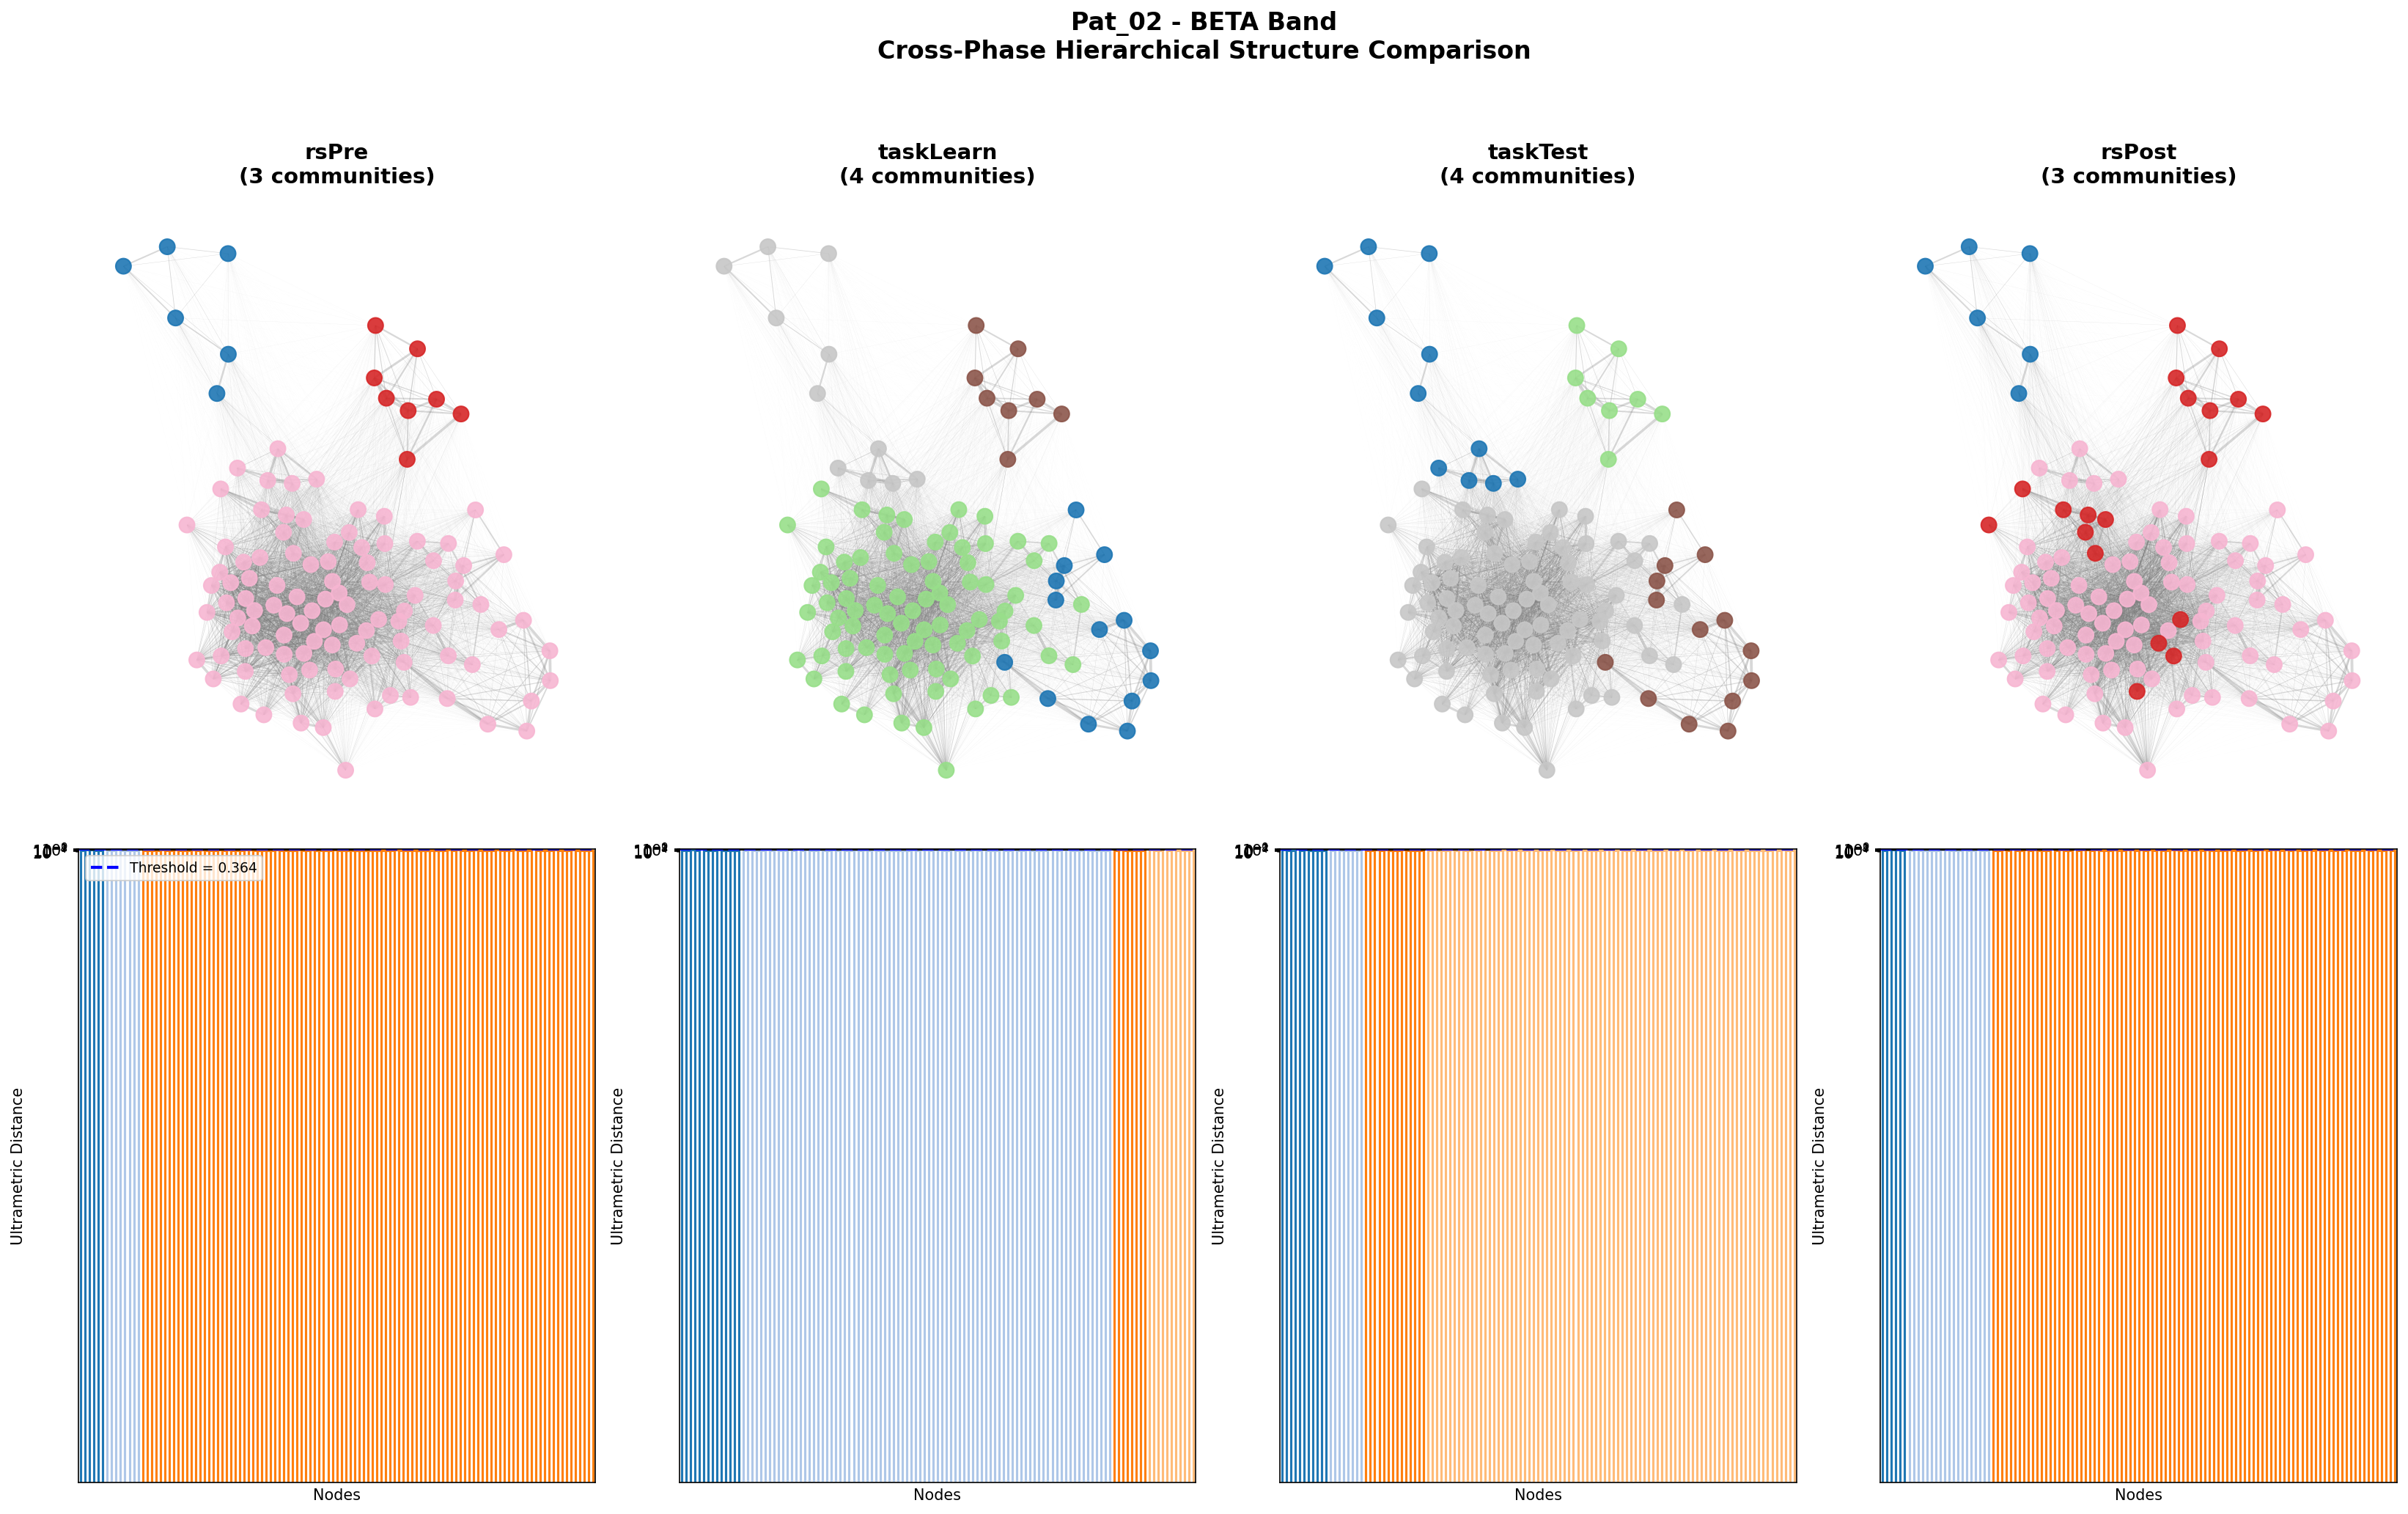

In [6]:
# Generate the 4-column figure
fig = create_four_phase_figure(
    lrg_results,
    msc_matrices,
    PHASES,
    BAND,
    PATIENT,
    k=LAYOUT_K,
    seed=LAYOUT_SEED,
)

output_path = OUTPUT_DIR / f"fig4_phase_comparison_{BAND}.pdf"
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

## Part 2: Multiscale ARI Analysis

Compute ARI curves across all threshold levels for each phase pair.

In [7]:
# Compute multiscale ARI for all phase pairs
phase_pairs = list(combinations(PHASES, 2))
n_nodes = lrg_results[PHASES[0]].n_nodes

ari_curves = {}
distances = {}

print("Computing multiscale ARI curves...")
print("="*60)

for phase_i, phase_j in phase_pairs:
    linkage_i = lrg_results[phase_i].linkage_matrix
    linkage_j = lrg_results[phase_j].linkage_matrix
    
    thresholds, ari_values = compute_multiscale_ari(
        linkage_i, linkage_j, n_nodes, N_THRESHOLDS
    )
    
    distance = compute_multiscale_structural_distance(
        linkage_i, linkage_j, n_nodes, N_THRESHOLDS
    )
    
    pair_key = f"{phase_i} vs {phase_j}"
    ari_curves[pair_key] = (thresholds, ari_values)
    distances[pair_key] = distance
    
    print(f"{pair_key}: D = {distance:.4f}")

print("\nDone!")

Computing multiscale ARI curves...
rsPre vs taskLearn: D = 0.5434
rsPre vs taskTest: D = 0.4559
rsPre vs rsPost: D = 0.2685
taskLearn vs taskTest: D = 0.1275
taskLearn vs rsPost: D = 0.5100
taskTest vs rsPost: D = 0.4683

Done!


Saved: data/figures/presentation_figures/Pat_02/fig4_multiscale_ari_beta.pdf


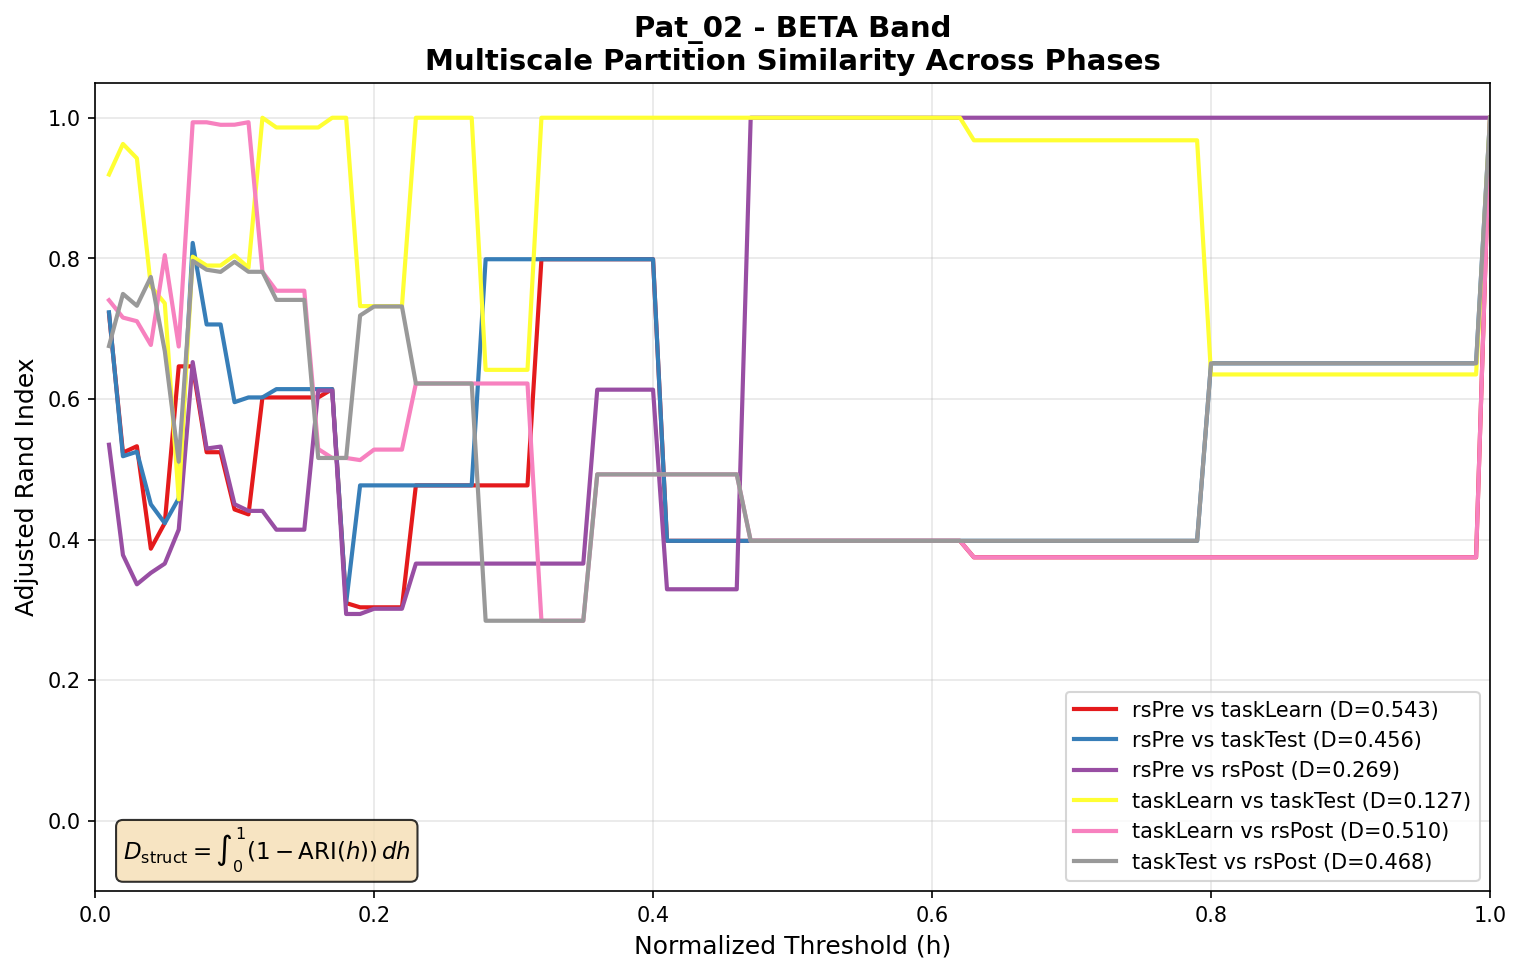

In [8]:
# Plot ARI curves
fig, ax = plt.subplots(figsize=(12, 7))

# Color map for different pairs
colors = plt.cm.Set1(np.linspace(0, 1, len(phase_pairs)))

for idx, (pair_key, (thresholds, ari_values)) in enumerate(ari_curves.items()):
    ax.plot(
        thresholds, ari_values,
        color=colors[idx],
        linewidth=2,
        label=f"{pair_key} (D={distances[pair_key]:.3f})"
    )

ax.set_xlabel('Normalized Threshold (h)', fontsize=12)
ax.set_ylabel('Adjusted Rand Index', fontsize=12)
ax.set_title(
    f"{PATIENT} - {BAND.upper()} Band\nMultiscale Partition Similarity Across Phases",
    fontsize=14, fontweight='bold'
)
ax.legend(fontsize=10, loc='lower right')
ax.grid(alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(-0.1, 1.05)

# Add annotation
ax.text(
    0.02, 0.02,
    r"$D_{\mathrm{struct}} = \int_0^1 (1 - \mathrm{ARI}(h))\, dh$",
    transform=ax.transAxes, fontsize=11,
    verticalalignment='bottom',
    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
)

output_path = OUTPUT_DIR / f"fig4_multiscale_ari_{BAND}.pdf"
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

## Part 3: Triangular Distance Matrix

In [9]:
# Compute full distance matrix
n_phases = len(PHASES)
dist_matrix = np.zeros((n_phases, n_phases))

for i, phase_i in enumerate(PHASES):
    for j, phase_j in enumerate(PHASES):
        if i < j:
            pair_key = f"{phase_i} vs {phase_j}"
            dist_matrix[i, j] = distances[pair_key]
            dist_matrix[j, i] = distances[pair_key]

print("Distance Matrix:")
print(dist_matrix.round(3))

Distance Matrix:
[[0.    0.543 0.456 0.269]
 [0.543 0.    0.127 0.51 ]
 [0.456 0.127 0.    0.468]
 [0.269 0.51  0.468 0.   ]]


In [ ]:
# Better visualization: Phase relationship network + MDS embedding
from sklearn.manifold import MDS

# Compute full distance matrix
n_phases = len(PHASES)
dist_matrix = np.zeros((n_phases, n_phases))

for i, phase_i in enumerate(PHASES):
    for j, phase_j in enumerate(PHASES):
        if i < j:
            pair_key = f"{phase_i} vs {phase_j}"
            dist_matrix[i, j] = distances[pair_key]
            dist_matrix[j, i] = distances[pair_key]

print("Distance Matrix:")
print(dist_matrix.round(3))

# Create 2-panel figure: MDS embedding + Phase network
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Use RdYlGn colormap consistently
cmap_similarity = plt.colormaps['RdYlGn']

# =========================================================================
# Panel 1: MDS Embedding of phases based on structural distance
# =========================================================================
ax_mds = axes[0]

# MDS to embed phases in 2D
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
phase_coords = mds.fit_transform(dist_matrix)

# Plot phases as large labeled nodes
phase_colors = plt.colormaps['Set2'](np.linspace(0, 1, n_phases))
for i, (phase, coord) in enumerate(zip(PHASES, phase_coords)):
    ax_mds.scatter(coord[0], coord[1], s=800, c=[phase_colors[i]],
                   edgecolors='black', linewidths=2, zorder=5)
    ax_mds.annotate(phase, coord, fontsize=12, fontweight='bold',
                   ha='center', va='center', zorder=10)

# Draw edges between phases - NO ALPHA so colorbar matches
for i in range(n_phases):
    for j in range(i+1, n_phases):
        dist = dist_matrix[i, j]
        similarity = 1 - dist

        # Edge width proportional to similarity
        width = max(1.0, similarity * 10)

        # Edge color from colormap - no alpha modification
        color = cmap_similarity(similarity)

        ax_mds.plot(
            [phase_coords[i, 0], phase_coords[j, 0]],
            [phase_coords[i, 1], phase_coords[j, 1]],
            color=color, linewidth=width, zorder=1
        )

ax_mds.set_title("Phase Structural Similarity\n(MDS embedding from distances)",
                 fontsize=13, fontweight='bold')
ax_mds.set_xlabel("MDS Dimension 1", fontsize=11)
ax_mds.set_ylabel("MDS Dimension 2", fontsize=11)
ax_mds.axis('equal')

# Add legend for edge colors - matches link colors exactly
sm = plt.cm.ScalarMappable(cmap=cmap_similarity, norm=plt.Normalize(0, 1))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax_mds, orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Structural Similarity (1-D)', fontsize=10)

# =========================================================================
# Panel 2: Temporal flow network (phases in experimental order)
# =========================================================================
ax_flow = axes[1]

# Arrange phases in a line (experimental order)
phase_positions = {
    PHASES[0]: (0, 0),
    PHASES[1]: (1, 0.3),
    PHASES[2]: (2, 0.3),
    PHASES[3]: (3, 0),
}

# Draw all pairwise connections - NO ALPHA
for i, phase_i in enumerate(PHASES):
    for j, phase_j in enumerate(PHASES):
        if i < j:
            pair_key = f"{phase_i} vs {phase_j}"
            dist = distances[pair_key]
            similarity = 1 - dist

            pos_i = phase_positions[phase_i]
            pos_j = phase_positions[phase_j]

            # Draw arc for non-adjacent phases
            if j - i > 1:
                # Draw curved line (arc)
                mid_x = (pos_i[0] + pos_j[0]) / 2
                mid_y = pos_i[1] - 0.3 * (j - i)  # Curve below

                # Bezier-like curve using multiple points
                t = np.linspace(0, 1, 50)
                x = (1-t)**2 * pos_i[0] + 2*(1-t)*t * mid_x + t**2 * pos_j[0]
                y = (1-t)**2 * pos_i[1] + 2*(1-t)*t * mid_y + t**2 * pos_j[1]

                width = max(1.0, similarity * 8)
                color = cmap_similarity(similarity)
                ax_flow.plot(x, y, color=color, linewidth=width, zorder=1)
            else:
                # Straight line for adjacent phases
                width = max(1.0, similarity * 8)
                color = cmap_similarity(similarity)
                ax_flow.plot(
                    [pos_i[0], pos_j[0]], [pos_i[1], pos_j[1]],
                    color=color, linewidth=width, zorder=1
                )

# Draw phase nodes
for i, phase in enumerate(PHASES):
    pos = phase_positions[phase]
    ax_flow.scatter(pos[0], pos[1], s=1200, c=[phase_colors[i]],
                   edgecolors='black', linewidths=2, zorder=5)
    ax_flow.annotate(phase, pos, fontsize=11, fontweight='bold',
                    ha='center', va='center', zorder=10)

# Add distance annotations on edges
for i, phase_i in enumerate(PHASES):
    for j, phase_j in enumerate(PHASES):
        if i < j:
            pair_key = f"{phase_i} vs {phase_j}"
            dist = distances[pair_key]

            pos_i = phase_positions[phase_i]
            pos_j = phase_positions[phase_j]

            if j - i == 1:
                # Adjacent: annotate on line
                mid_x = (pos_i[0] + pos_j[0]) / 2
                mid_y = (pos_i[1] + pos_j[1]) / 2 + 0.15
                ax_flow.annotate(f"D={dist:.2f}", (mid_x, mid_y), fontsize=9,
                               ha='center', va='bottom', color='darkblue')

# Add arrows showing experimental flow
for i in range(n_phases - 1):
    pos_i = phase_positions[PHASES[i]]
    pos_j = phase_positions[PHASES[i+1]]
    mid_x = (pos_i[0] + pos_j[0]) / 2
    mid_y = (pos_i[1] + pos_j[1]) / 2 - 0.25
    ax_flow.annotate('', xy=(pos_j[0] - 0.15, pos_j[1] - 0.1),
                    xytext=(pos_i[0] + 0.15, pos_i[1] - 0.1),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))

ax_flow.set_title("Experimental Timeline\n(edge width = structural similarity)",
                  fontsize=13, fontweight='bold')
ax_flow.set_xlim(-0.5, 3.5)
ax_flow.set_ylim(-0.8, 0.8)
ax_flow.axis('off')

fig.suptitle(
    f"{PATIENT} - {BAND.upper()} Band | Phase Structural Distances",
    fontsize=16, fontweight='bold', y=1.02
)

plt.tight_layout()

output_path = OUTPUT_DIR / f"fig4_phase_distances_{BAND}.pdf"
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

In [ ]:
def create_full_comparison_figure(
    lrg_results: dict,
    msc_matrices: dict,
    phases: list,
    band: str,
    patient: str,
    ari_curves: dict,
    distances: dict,
    k: float = 0.1,
    seed: int = 42,
    figsize: tuple = (24, 18),
    edge_power: float = 2.0,
    max_width: float = 4.0,
    n_communities: int = 8,
) -> plt.Figure:
    """Create comprehensive comparison figure with MATCHED cluster colors.

    Layout:
    - Top: 4-column networks (colors matched across phases)
    - Middle: 4-column dendrograms (log scale, colored branches)
    - Bottom-left: ARI curves
    - Bottom-right: MDS phase embedding
    """
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(3, 4, figure=fig, height_ratios=[1, 1, 1.2],
                          hspace=0.35, wspace=0.25)

    n_phases = len(phases)

    # Compute shared layout using backbone
    G_first = nx.from_numpy_array(msc_matrices[phases[0]])
    weights_first = np.array([G_first[u][v]["weight"] for u, v in G_first.edges()])
    layout_threshold = np.percentile(weights_first, 75)

    G_backbone = nx.Graph()
    G_backbone.add_nodes_from(G_first.nodes())
    for u, v in G_first.edges():
        if G_first[u][v]["weight"] >= layout_threshold:
            G_backbone.add_edge(u, v, weight=G_first[u][v]["weight"])
    shared_pos = nx.spring_layout(G_backbone, seed=seed, k=k, iterations=100)

    # COMPUTE MATCHED CLUSTER COLORS ACROSS ALL PHASES
    phase_node_colors, cluster_assignments, phase_cluster_color_maps = compute_matched_cluster_colors(
        lrg_results, phases, n_communities, reference_phase=phases[0]
    )

    cmap_edges = plt.colormaps['viridis']

    # =========================================================================
    # ROW 1: Networks with matched colors
    # =========================================================================
    for i, phase in enumerate(phases):
        lrg = lrg_results[phase]
        msc = msc_matrices[phase]
        node_colors = phase_node_colors[phase]
        labels = cluster_assignments[phase]
        n_clusters = len(np.unique(labels))

        ax_net = fig.add_subplot(gs[0, i])
        G = nx.from_numpy_array(msc)
        edges = list(G.edges(data=True))
        weights = np.array([e[2]['weight'] for e in edges])

        scaled = np.power(weights, edge_power)
        widths = max_width * scaled
        alphas = np.power(weights, edge_power)
        edge_colors = [(*cmap_edges(w)[:3], a) for w, a in zip(weights, alphas)]

        nx.draw_networkx_nodes(G, shared_pos, ax=ax_net, node_size=60,
                               node_color=node_colors, alpha=0.9,
                               edgecolors='white', linewidths=0.3)
        nx.draw_networkx_edges(G, shared_pos, ax=ax_net, width=widths, edge_color=edge_colors)
        ax_net.set_title(f"{phase}\n({n_clusters} comm.)", fontsize=13, fontweight='bold')
        ax_net.axis('off')

    # =========================================================================
    # ROW 2: Dendrograms with colored branches
    # =========================================================================
    for i, phase in enumerate(phases):
        lrg = lrg_results[phase]
        n_nodes = lrg.n_nodes
        labels = cluster_assignments[phase]
        cluster_color_map = phase_cluster_color_maps[phase]

        merge_heights = lrg.linkage_matrix[:, 2]
        cut_idx = n_nodes - n_communities
        if cut_idx < len(merge_heights) and cut_idx > 0:
            threshold = (merge_heights[cut_idx - 1] + merge_heights[cut_idx]) / 2
        elif cut_idx == 0:
            threshold = merge_heights[0] / 2
        else:
            threshold = lrg.optimal_threshold

        ax_dendro = fig.add_subplot(gs[1, i])

        link_color_func = get_link_color_func(
            lrg.linkage_matrix, labels, cluster_color_map, n_nodes, threshold
        )

        dendro = dendrogram(
            lrg.linkage_matrix, ax=ax_dendro, orientation='top',
            no_labels=True, link_color_func=link_color_func,
        )

        ax_dendro.axhline(threshold, color='blue', linestyle='--', lw=2)
        heights = lrg.linkage_matrix[:, 2]
        tmin = heights[0] * 0.8
        tmax = heights[-1] * 1.01
        ax_dendro.set_yscale('log')
        ax_dendro.set_ylim(tmin, tmax)
        ax_dendro.set_ylabel(r'$\mathcal{D}$', fontsize=9)
        ax_dendro.grid(alpha=0.2)

    # =========================================================================
    # Row 3: ARI curves + MDS embedding
    # =========================================================================
    ax_ari = fig.add_subplot(gs[2, 0:2])
    colors = plt.colormaps['tab10'](np.linspace(0, 1, len(ari_curves)))

    for idx, (pair_key, (thresholds, ari_values)) in enumerate(ari_curves.items()):
        ax_ari.plot(thresholds, ari_values, color=colors[idx], linewidth=2,
                   label=f"{pair_key} (D={distances[pair_key]:.3f})")

    ax_ari.set_xlabel('Normalized Threshold (h)', fontsize=11)
    ax_ari.set_ylabel('Adjusted Rand Index', fontsize=11)
    ax_ari.set_title('Multiscale Partition Similarity', fontsize=13, fontweight='bold')
    ax_ari.legend(fontsize=8, loc='lower right')
    ax_ari.grid(alpha=0.3)
    ax_ari.set_xlim(0, 1)
    ax_ari.set_ylim(-0.1, 1.05)

    # MDS embedding - NO ALPHA on links so colorbar matches exactly
    ax_mds = fig.add_subplot(gs[2, 2:4])

    dist_matrix = np.zeros((n_phases, n_phases))
    for i, phase_i in enumerate(phases):
        for j, phase_j in enumerate(phases):
            if i < j:
                pair_key = f"{phase_i} vs {phase_j}"
                dist_matrix[i, j] = distances[pair_key]
                dist_matrix[j, i] = distances[pair_key]

    from sklearn.manifold import MDS
    mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
    phase_coords = mds.fit_transform(dist_matrix)

    # Use RdYlGn colormap for edges - NO ALPHA so colorbar matches exactly
    cmap_similarity = plt.colormaps['RdYlGn']

    phase_colors_mds = plt.colormaps['Set2'](np.linspace(0, 1, n_phases))
    for i in range(n_phases):
        for j in range(i+1, n_phases):
            dist = dist_matrix[i, j]
            similarity = 1 - dist
            width = max(1.0, similarity * 10)
            color = cmap_similarity(similarity)  # No alpha modification
            ax_mds.plot([phase_coords[i, 0], phase_coords[j, 0]],
                       [phase_coords[i, 1], phase_coords[j, 1]],
                       color=color, linewidth=width, zorder=1)  # No alpha parameter

    for i, (phase, coord) in enumerate(zip(phases, phase_coords)):
        ax_mds.scatter(coord[0], coord[1], s=600, c=[phase_colors_mds[i]],
                      edgecolors='black', linewidths=2, zorder=5)
        ax_mds.annotate(phase, coord, fontsize=11, fontweight='bold',
                       ha='center', va='center', zorder=10)

    ax_mds.set_title('Phase Structural Similarity\n(MDS from distances)',
                     fontsize=13, fontweight='bold')
    ax_mds.axis('equal')
    ax_mds.axis('off')

    # Colorbar - uses same colormap as edges
    sm = plt.cm.ScalarMappable(cmap=cmap_similarity, norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax_mds, orientation='vertical', fraction=0.046, pad=0.04)
    cbar.set_label('Similarity (1-D)', fontsize=9)

    fig.suptitle(
        f"{patient} - {band.upper()} Band | Cross-Phase Structural Reorganization",
        fontsize=18, fontweight='bold', y=0.99
    )

    return fig

In [ ]:
# Generate the full combined figure with matched colors (FINAL VERSION v8)
fig = create_full_comparison_figure(
    lrg_results,
    msc_matrices,
    PHASES,
    BAND,
    PATIENT,
    ari_curves,
    distances,
    k=LAYOUT_K,
    seed=LAYOUT_SEED,
)

output_path = OUTPUT_DIR / f"fig4_full_comparison_{BAND}_v8.pdf"
fig.savefig(output_path, dpi=150, bbox_inches='tight')

output_png = OUTPUT_DIR / f"fig4_full_comparison_{BAND}_v8.png"
fig.savefig(output_png, dpi=100, bbox_inches='tight')

print(f"Saved: {output_path}")
print(f"Saved: {output_png}")
plt.show()

Saved: data/figures/presentation_figures/Pat_02/fig4_full_comparison_beta.pdf


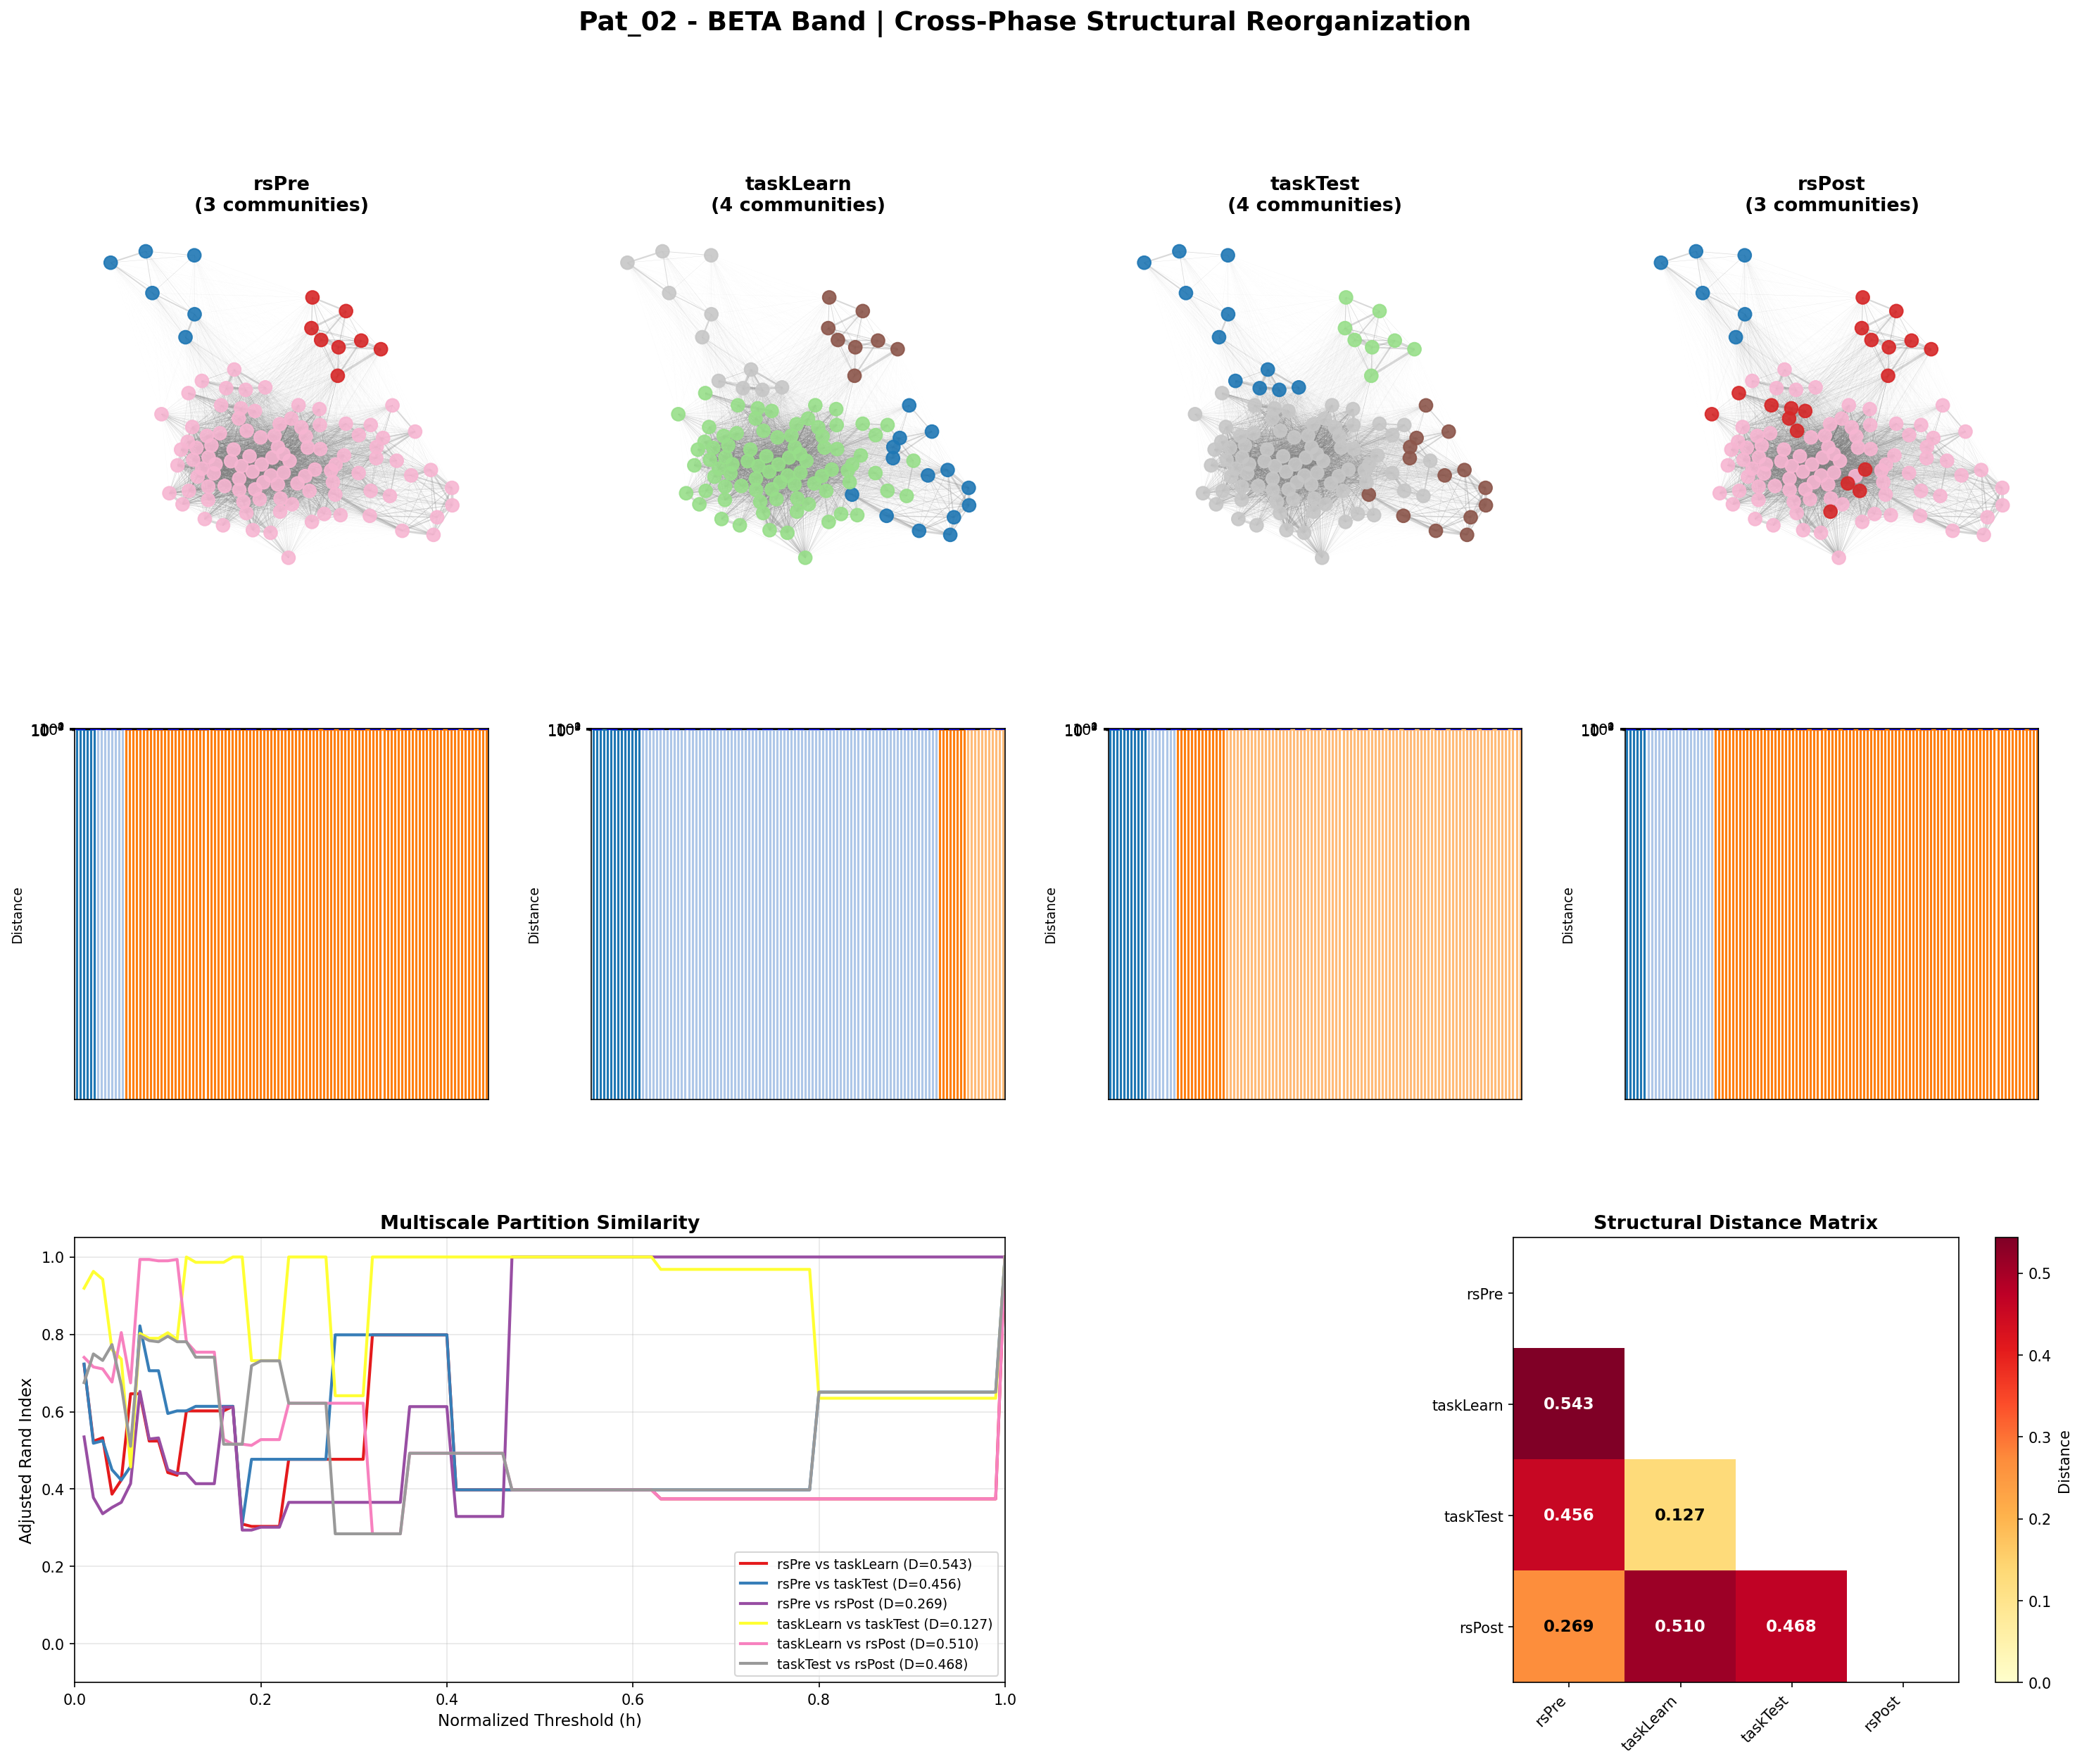

In [12]:
# Generate the full combined figure
fig = create_full_comparison_figure(
    lrg_results,
    msc_matrices,
    PHASES,
    BAND,
    PATIENT,
    ari_curves,
    distances,
    k=LAYOUT_K,
    seed=LAYOUT_SEED,
)

output_path = OUTPUT_DIR / f"fig4_full_comparison_{BAND}.pdf"
fig.savefig(output_path, dpi=150, bbox_inches='tight')
print(f"Saved: {output_path}")
plt.show()

## Interpretation

### What to look for:

1. **ARI Curves**: 
   - Curves that stay high → similar structures at most scales
   - Curves that drop at low h → structures diverge at fine scales
   - Curves that drop at high h → structures diverge at coarse scales

2. **Distance Matrix**:
   - Low values between rsPre and rsPost → stable resting state
   - High values between rest and task → task-induced reorganization
   - Asymmetric patterns → directional changes through protocol

3. **Network visualizations**:
   - Same position, different colors → reorganization of community structure
   - Consistent colors → stable community assignment

In [13]:
# Summary statistics
print("\n" + "="*60)
print("SUMMARY: Structural Distances")
print("="*60)
print(f"\nBand: {BAND}")
print(f"Patient: {PATIENT}")
print("\nPairwise distances:")

for pair_key, dist in sorted(distances.items(), key=lambda x: x[1]):
    print(f"  {pair_key}: D = {dist:.4f}")

# Find most and least similar pairs
min_pair = min(distances.items(), key=lambda x: x[1])
max_pair = max(distances.items(), key=lambda x: x[1])

print(f"\nMost similar: {min_pair[0]} (D = {min_pair[1]:.4f})")
print(f"Most different: {max_pair[0]} (D = {max_pair[1]:.4f})")


SUMMARY: Structural Distances

Band: beta
Patient: Pat_02

Pairwise distances:
  taskLearn vs taskTest: D = 0.1275
  rsPre vs rsPost: D = 0.2685
  rsPre vs taskTest: D = 0.4559
  taskTest vs rsPost: D = 0.4683
  taskLearn vs rsPost: D = 0.5100
  rsPre vs taskLearn: D = 0.5434

Most similar: taskLearn vs taskTest (D = 0.1275)
Most different: rsPre vs taskLearn (D = 0.5434)


In [14]:
print("\n" + "="*60)
print("FIGURE 4 GENERATION COMPLETE")
print("="*60)
print(f"\nOutput directory: {OUTPUT_DIR}")
print("\nGenerated files:")
for f in sorted(OUTPUT_DIR.glob("fig4_*")):
    print(f"  {f.name}")


FIGURE 4 GENERATION COMPLETE

Output directory: data/figures/presentation_figures/Pat_02

Generated files:
  fig4_distance_matrix_beta.pdf
  fig4_full_comparison_beta.pdf
  fig4_multiscale_ari_beta.pdf
  fig4_phase_comparison_beta.pdf
